# End-Quarter Presentation
**Group 8: Lin Xi, Yingqi Chen**

### Initialize & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

In [2]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

**Universe Construction**

- The stock universe is constructed using CRSP monthly stock files. We keep only common stocks (share codes 10 and 11) listed on NYSE, AMEX, and NASDAQ (exchange codes 1–3). The CRSP dataset used in this project was pre-filtered during the data availability check and preprocessing stage in mid-quarter presentation.

- Financial firms are excluded following the original paper because their accounting structure differs substantially from nonfinancial firms. Firms with SICH codes between 6000 and 6999 are removed. (Used SIC if SICH is not available.)

- This filtering ensures consistency with standard asset pricing research and improves comparability with the results reported in the paper.

In [3]:
# Load Compustat Annual
comp = pd.read_parquet("raw_compustat_funda_1961_2012.parquet")

comp['datadate'] = pd.to_datetime(comp['datadate'])
comp.sort_values(by='datadate')

print("Compustat shape:", comp.shape)
print(comp.head())

Compustat shape: (432594, 17)
    gvkey   datadate  fyear     revt     cogs       at   sic  sich    seq  \
0  001000 1961-12-31   1961   0.9000     <NA>     <NA>  3089  <NA>   <NA>   
1  001002 1961-12-31   1961   8.0000     <NA>     <NA>  3825  <NA>   <NA>   
2  001187 1961-12-31   1961   0.9750   0.9910   0.9460  1000  <NA> 0.5910   
3  001040 1961-12-31   1961 516.5000 382.5800 366.6000  3949  <NA>   <NA>   
4  001010 1962-04-30   1961 214.3000 168.5700 251.2000  3743  <NA>   <NA>   

     ceq   pstk       lt  txditc    txdb   itcb  pstkrv  pstkl  
0   <NA>   <NA>     <NA>  0.0000  0.0000 0.0000    <NA> 0.0000  
1   <NA>   <NA>     <NA>    <NA>    <NA>   <NA>    <NA> 0.0000  
2 0.5910 0.0000     <NA>    <NA>    <NA> 0.0000  0.0000 0.0000  
3   <NA>   <NA> 212.7460 13.7010 13.7010   <NA>  7.4590 7.2000  
4   <NA>   <NA> 128.3160 11.5620 11.5620   <NA>  0.0000 0.0000  


In [4]:
# Keep relevant variables only (now including both sic and sich)
comp = comp[['gvkey', 'datadate', 'fyear', 'revt', 'cogs', 'at', 'sic', 'sich', 
             'seq', 'ceq', 'pstk', 'lt', 'txditc', 'txdb', 'itcb', 'pstkrv', 'pstkl']]

# Combine sic and sich: Use sich if available, otherwise fallback to sic
# (Ensure both are numeric so we don't get string comparison errors)
comp['sic'] = pd.to_numeric(comp['sic'], errors='coerce')
comp['sich'] = pd.to_numeric(comp['sich'], errors='coerce')

comp['industry_code'] = comp['sich'].fillna(comp['sic'])

# Exclude financial firms (SIC 6000–6999)
comp = comp[(comp['industry_code'] < 6000) | (comp['industry_code'] >= 7000)]

print("Compustat shape:", comp.shape)
print(comp.head())

Compustat shape: (343546, 18)
    gvkey   datadate  fyear     revt     cogs       at   sic  sich    seq  \
0  001000 1961-12-31   1961   0.9000     <NA>     <NA>  3089  <NA>   <NA>   
1  001002 1961-12-31   1961   8.0000     <NA>     <NA>  3825  <NA>   <NA>   
2  001187 1961-12-31   1961   0.9750   0.9910   0.9460  1000  <NA> 0.5910   
3  001040 1961-12-31   1961 516.5000 382.5800 366.6000  3949  <NA>   <NA>   
4  001010 1962-04-30   1961 214.3000 168.5700 251.2000  3743  <NA>   <NA>   

     ceq   pstk       lt  txditc    txdb   itcb  pstkrv  pstkl  industry_code  
0   <NA>   <NA>     <NA>  0.0000  0.0000 0.0000    <NA> 0.0000           3089  
1   <NA>   <NA>     <NA>    <NA>    <NA>   <NA>    <NA> 0.0000           3825  
2 0.5910 0.0000     <NA>    <NA>    <NA> 0.0000  0.0000 0.0000           1000  
3   <NA>   <NA> 212.7460 13.7010 13.7010   <NA>  7.4590 7.2000           3949  
4   <NA>   <NA> 128.3160 11.5620 11.5620   <NA>  0.0000 0.0000           3743  


In [5]:
comp['datadate'].min()

Timestamp('1961-06-30 00:00:00')

In [6]:
# Load CRSP Monthly (merged with msenames and filtered)
# CRSP dataset was already filtered during preprocessing:
# - share codes: 10, 11 (common stocks)
# - exchange codes: 1, 2, 3 (NYSE, AMEX, NASDAQ)
# - valid monthly returns only
crsp = pd.read_parquet("crsp_msf_msenames_filtered_1961_2012.parquet")

crsp['date'] = pd.to_datetime(crsp['date'])

# Ensure numeric returns
crsp['ret'] = pd.to_numeric(crsp['ret'], errors='coerce')
crsp['retx'] = pd.to_numeric(crsp['retx'], errors='coerce')

print("CRSP shape:", crsp.shape)
print(crsp.head())

CRSP shape: (2904107, 12)
   permno  permco       date     ret    retx     prc    shrout         me  \
0   10000    7952 1986-01-31    <NA>    <NA> -4.3750 3680.0000 16100.0000   
1   10000    7952 1986-02-28 -0.2571 -0.2571 -3.2500 3680.0000 11960.0000   
2   10000    7952 1986-03-31  0.3654  0.3654 -4.4375 3680.0000 16330.0000   
3   10000    7952 1986-04-30 -0.0986 -0.0986 -4.0000 3793.0000 15172.0000   
4   10000    7952 1986-05-30 -0.2227 -0.2227 -3.1094 3793.0000 11793.8783   

      namedt   nameendt  shrcd  exchcd  
0 1986-01-07 1986-12-03     10       3  
1 1986-01-07 1986-12-03     10       3  
2 1986-01-07 1986-12-03     10       3  
3 1986-01-07 1986-12-03     10       3  
4 1986-01-07 1986-12-03     10       3  


In [7]:
# Load Delisting Returns
# Delisting returns are merged into CRSP monthly returns later to avoid
# survivorship bias. Firms that delist (especially due to distress) would
# otherwise have their final return treated as missing, biasing results.
dlret = pd.read_parquet("msedelist.parquet")

dlret['dlstdt'] = pd.to_datetime(dlret['dlstdt'])

# Create a year-month key for merging with CRSP
dlret['ym'] = dlret['dlstdt'].dt.to_period('M')

print("Delisting shape:", dlret.shape)
print(dlret.head())

Delisting shape: (38843, 4)
   permno  dlret     dlstdt       ym
0   10000 0.0000 1987-06-11  1987-06
1   10001 0.0116 2017-08-03  2017-08
2   10002 0.0460 2013-02-15  2013-02
3   10003 0.0137 1995-12-15  1995-12
4   10005 0.1250 1991-07-11  1991-07


In [8]:
# Load CCM Link Table
ccm = pd.read_parquet("raw_ccm_linktable.parquet")

ccm['linkdt'] = pd.to_datetime(ccm['linkdt'])
ccm['linkenddt'] = pd.to_datetime(ccm['linkenddt'])

print("CCM shape:", ccm.shape)

CCM shape: (33324, 7)


In [9]:
# Load Fama-French Factors
ff_factors = pd.read_parquet("raw_ff_factors_monthly_1961_2012.parquet")

ff_factors['date'] = pd.to_datetime(ff_factors['date'])

print("FF factors shape:", ff_factors.shape)

FF factors shape: (624, 6)


### Construct Gross Profitability (GP/A)

In [10]:
# Cleaning

# Drop missing core accounting variables
comp = comp.dropna(subset=['revt', 'cogs', 'at'])

# Remove firms with non-positive assets
comp = comp[comp['at'] > 0]

# Construct Gross Profit
comp['gp'] = comp['revt'] - comp['cogs']

# Construct Gross Profitability: GP/A = (Revenue - COGS) / Total Assets
# Following Novy-Marx (2013): use book assets (not book equity) as denominator
# because gross profit is an asset-level measure independent of leverage
comp['gpa'] = comp['gp'] / comp['at']

In [11]:
# Remove Extreme Accounting Noise

# Remove infinite values
comp = comp.replace([np.inf, -np.inf], np.nan)
comp = comp.dropna(subset=['gpa'])

# Cross-sectional Winsorization (by fyear)
def winsorize_by_year(group, col):
    lower = group[col].quantile(0.01)
    upper = group[col].quantile(0.99)
    group[col] = group[col].clip(lower, upper)
    return group

comp = comp.groupby('fyear', group_keys=False).apply(lambda x: winsorize_by_year(x, 'gpa'))

# Construct Book Equity (Fama-French 1993 Definition)
# Step A: Shareholders' Equity
comp['she'] = comp['seq'].fillna(comp['ceq'] + comp['pstk'].fillna(0)).fillna(comp['at'] - comp['lt'])

# Step B: Deferred Taxes
comp['dt'] = comp['txditc'].fillna(comp['txdb'].fillna(0) + comp['itcb'].fillna(0))

# Step C: Preferred Stock 
comp['ps'] = comp['pstkrv'].fillna(comp['pstkl']).fillna(comp['pstk']).fillna(0)

# Final Book Equity
comp['be'] = comp['she'] + comp['dt'] - comp['ps']

# Keep all firms for GP/A signal; BE may be NaN for some firms (kept for B/M later)
comp = comp[['gvkey', 'datadate', 'fyear', 'gpa', 'be']]

print("Post-clean Compustat shape:", comp.shape)
print(comp.describe())

Post-clean Compustat shape: (319404, 5)
                         datadate       fyear         gpa           be
count                      319404 319404.0000 319404.0000  318450.0000
mean   1991-11-08 02:56:48.889056   1990.8989      0.3239     623.6680
min           1961-06-30 00:00:00   1961.0000     -3.1762 -534791.0000
25%           1981-06-30 00:00:00   1981.0000      0.1338       4.1860
50%           1993-09-30 00:00:00   1993.0000      0.2906      27.7710
75%           2002-12-31 00:00:00   2002.0000      0.4888     168.4580
max           2013-05-31 00:00:00   2012.0000      2.0869  289771.0000
std                           NaN     13.3228      0.3658    4268.7376


/var/folders/mr/pbjp00px3gv04rs31k45rj740000gn/T/ipykernel_52714/2095751646.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  comp = comp.groupby('fyear', group_keys=False).apply(lambda x: winsorize_by_year(x, 'gpa'))


### Link Compustat to CRSP

In [12]:
# Prepare CCM

# Replace missing linkenddt with large future date
ccm['linkenddt'] = ccm['linkenddt'].fillna(pd.Timestamp('2099-12-31'))

# Keep only necessary columns
ccm = ccm[['gvkey', 'permno', 'linkdt', 'linkenddt']]


# Merge Compustat with CCM
comp_ccm = comp.merge(ccm, on='gvkey', how='left')


# Valid Link Date
comp_ccm = comp_ccm[
    (comp_ccm['datadate'] >= comp_ccm['linkdt']) &
    (comp_ccm['datadate'] <= comp_ccm['linkenddt'])
]


# Drop duplicates (if any)
comp_ccm = comp_ccm.drop_duplicates(subset=['gvkey', 'datadate', 'permno'])


# Keep Necessary Columns
comp_ccm = comp_ccm[['gvkey', 'datadate', 'fyear', 'gpa', 'permno', 'be']]

print("Linked dataset shape:", comp_ccm.shape)
print(comp_ccm.head())

Linked dataset shape: (204790, 6)
     gvkey   datadate  fyear    gpa     permno       be
1   001040 1961-12-31   1961 0.3653 15763.0000 160.0960
4   001010 1962-04-30   1961 0.1820 10006.0000 134.4460
7   001031 1962-03-31   1961 0.2570 10014.0000  12.9480
9   001043 1961-07-31   1961 0.7969 18980.0000  85.6000
14  001045 1961-12-31   1961 0.0916 21020.0000 188.9190


In [13]:
comp_ccm['permno'].isna().mean()

0.0

### Portfolio Formation Timing (June Formation Rule)

In [14]:
# Construct formation year
# Following Fama-French convention: use accounting data from fiscal year t,
# available at end of June of year t+1, to form portfolios
comp_ccm['formation_year'] = comp_ccm['fyear'] + 1

# Construct June formation date
comp_ccm['formation_date'] = pd.to_datetime(
    comp_ccm['formation_year'].astype(str) + '-06-30'
)

# Keep only necessary columns
signal = comp_ccm[['permno', 'gpa', 'formation_year', 'formation_date', 'be']]

print("Signal dataset shape:", signal.shape)
print(signal.head())

Signal dataset shape: (204790, 5)
       permno    gpa  formation_year formation_date       be
1  15763.0000 0.3653            1962     1962-06-30 160.0960
4  10006.0000 0.1820            1962     1962-06-30 134.4460
7  10014.0000 0.2570            1962     1962-06-30  12.9480
9  18980.0000 0.7969            1962     1962-06-30  85.6000
14 21020.0000 0.0916            1962     1962-06-30 188.9190


In [15]:
print(signal['formation_year'].min())
print(signal['formation_year'].max())

1962
2013


Add B/M (For table 2 replication)

In [16]:
# 1. Extract December Market Equity from CRSP
crsp_monthly = crsp.copy()
crsp_monthly['year'] = crsp_monthly['date'].dt.year
crsp_monthly['month'] = crsp_monthly['date'].dt.month

dec_me = crsp_monthly[crsp_monthly['month'] == 12][['permno', 'year', 'me']].copy()
dec_me = dec_me.rename(columns={'me': 'me_dec'})

# 2. Align December ME(t-1) with June formation(t)
# To merge with June formation year t, we need Dec ME from year t-1.
dec_me['formation_year'] = dec_me['year'] + 1
dec_me = dec_me[['permno', 'formation_year', 'me_dec']]

# 3. Merge into the signal dataframe
signal = signal.merge(dec_me, on=['permno', 'formation_year'], how='left')

# 4. Calculate Book-to-Market (B/M)
signal['bm'] = signal['be'] / (signal['me_dec'] / 1000)

# 5. Keep all firms; B/M may be NaN for firms missing December ME or BE
# This preserves full coverage for GP/A signal — B/M used only as descriptor
signal['bm'] = signal['bm'].where(signal['bm'] > 0, np.nan)

print("Signal shape with B/M:", signal.shape)
print(signal[['permno', 'formation_year', 'gpa', 'bm']].describe())

Signal shape with B/M: (204790, 7)
           permno  formation_year         gpa          bm
count 204790.0000     204790.0000 204790.0000 174745.0000
mean   55250.2261       1991.7086      0.3522      0.8988
std    26569.7473         12.6064      0.3045      1.0728
min    10000.0000       1962.0000     -3.1762      0.0001
25%    30648.0000       1982.0000      0.1690      0.3476
50%    58640.0000       1993.0000      0.3236      0.6448
75%    79864.0000       2002.0000      0.5042      1.1221
max    93436.0000       2013.0000      2.0869    114.0624


### Comparison with WRDS Pre-Built Signal

The WRDS Factor Library provides a pre-built gross profitability signal (gprof). We compare our replicated GP/A against this signal on the overlapping sample. 

Any differences are expected to stem from: (1) COGS definition differences, (2) timing conventions, (3) universe filters, or (4) winsorization choices.

Overlapping observations: 177979
   permno    gpa  formation_year  gprof
0   15763 0.3653            1962 0.3653
1   10006 0.1820            1962 0.1820
2   10014 0.2570            1962 0.2570
3   18980 0.7969            1962 0.7969
4   21020 0.0916            1962 0.0916
Correlation (ours vs WRDS):     0.9327
Mean difference (ours - WRDS):  0.003068
Mean absolute error:            0.044456
Firm coverage by year (sample):
                Our Signal  WRDS Signal
formation_year                         
1999             6262.0000         6762
2000             6024.0000         6509
2001             5893.0000         6098
2002             5298.0000         5558
2003             4895.0000         5153
2004             4596.0000         4920
2005             4556.0000         4890
2006             4463.0000         4813
2007             4408.0000         4702
2008             4301.0000         4615
2009             4080.0000         4288
2010             3861.0000         4120
2011          

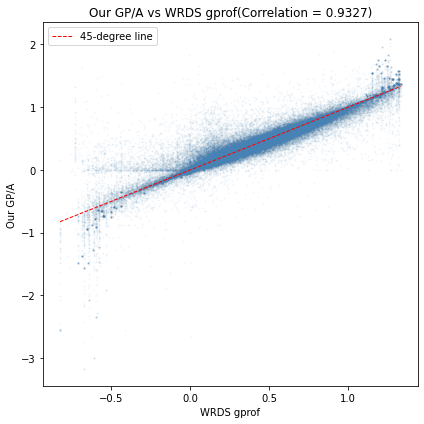

Summary of construction differences:
  Our universe size (avg per year):   3938 firms
  WRDS universe size (avg per year):  4411 firms
  Our GP/A mean:   0.3522
  WRDS gprof mean: 0.2980


In [17]:
# Load WRDS pre-built GP/A signal
wrds_gpa = pd.read_parquet('wrds_gpa_signal.parquet')
wrds_gpa['fdate'] = pd.to_datetime(wrds_gpa['fdate'])
wrds_gpa['permno'] = wrds_gpa['permno'].astype('int64')

# WRDS signal is monthly frequency; keep only June observations to align
# with our annual June formation convention
wrds_june = wrds_gpa[wrds_gpa['fdate'].dt.month == 6].copy()
wrds_june['formation_year'] = wrds_june['fdate'].dt.year

# Prepare our replicated signal
our_signal = signal[['permno', 'gpa', 'formation_year']].copy()
our_signal['permno'] = our_signal['permno'].astype('int64')

# Merge on permno + formation_year
comparison = our_signal.merge(
    wrds_june[['permno', 'formation_year', 'gprof']],
    on=['permno', 'formation_year'],
    how='inner'
)

print(f'Overlapping observations: {len(comparison)}')
print(comparison.head())

# Numerical comparison
corr      = comparison['gpa'].corr(comparison['gprof'])
mean_diff = (comparison['gpa'] - comparison['gprof']).mean()
mae       = (comparison['gpa'] - comparison['gprof']).abs().mean()

print(f'Correlation (ours vs WRDS):     {corr:.4f}')
print(f'Mean difference (ours - WRDS):  {mean_diff:.6f}')
print(f'Mean absolute error:            {mae:.6f}')

# Coverage comparison by year
our_coverage  = our_signal.groupby('formation_year')['permno'].nunique()
wrds_coverage = wrds_june.groupby('formation_year')['permno'].nunique()

coverage_compare = pd.DataFrame({
    'Our Signal' : our_coverage,
    'WRDS Signal': wrds_coverage
}).dropna()

print('Firm coverage by year (sample):')
print(coverage_compare.tail(15).to_string())

# Scatter plot: our GP/A vs WRDS gprof
plt.figure(figsize=(6, 6))
plt.scatter(comparison['gprof'], comparison['gpa'],
            alpha=0.05, s=1, color='steelblue')
plt.plot(
    [comparison['gprof'].min(), comparison['gprof'].max()],
    [comparison['gprof'].min(), comparison['gprof'].max()],
    color='red', linewidth=1, linestyle='--', label='45-degree line'
)
plt.xlabel('WRDS gprof')
plt.ylabel('Our GP/A')
plt.title(f'Our GP/A vs WRDS gprof(Correlation = {corr:.4f})')
plt.legend()
plt.tight_layout()
plt.show()

# Summary of differences
# Expected sources of discrepancy:
# 1. Winsorization: we winsorize at 1%/99% pooled; WRDS may differ
# 2. Universe: we exclude financials (SIC 6000-6999); WRDS inclusion may vary
# 3. COGS definition: Compustat COGS vs WRDS internal calculation
# 4. Timing: both use June formation, but fiscal year-end handling may differ
print('Summary of construction differences:')
print(f'  Our universe size (avg per year):   {our_coverage.mean():.0f} firms')
print(f'  WRDS universe size (avg per year):  {wrds_coverage.mean():.0f} firms')
our_gpa_mean = our_signal["gpa"].mean()
print(f"  Our GP/A mean:   {our_gpa_mean:.4f}")
wrds_gprof_mean = wrds_june["gprof"].mean()
print(f"  WRDS gprof mean: {wrds_gprof_mean:.4f}")

Our replicated signal achieves a correlation of 0.933 with the WRDS pre-built gprof signal, indicating strong consistency in construction. The small mean difference suggests low systematic bias. The coverage gap (~250 fewer firms per year) is primarily due to our stricter financial firm exclusion (SIC 6000-6999) and the requirement that both REVT and COGS be non-missing, whereas WRDS may impute missing COGS values.

### Match Monthly Returns to Formation Portfolios

In [18]:
# Prepare CRSP monthly data
crsp_monthly = crsp.copy()

# Extract year and month
crsp_monthly['year'] = crsp_monthly['date'].dt.year
crsp_monthly['month'] = crsp_monthly['date'].dt.month

# Construct portfolio year:
# July–December of year t  → portfolio_year = t   (use signal formed in June t)
# January–June  of year t  → portfolio_year = t-1 (use signal formed in June t-1)
crsp_monthly['portfolio_year'] = np.where(
    crsp_monthly['month'] >= 7,
    crsp_monthly['year'],
    crsp_monthly['year'] - 1
)

# Merge with signal
merged = crsp_monthly.merge(
    signal,
    left_on=['permno', 'portfolio_year'],
    right_on=['permno', 'formation_year'],
    how='inner'
)

# Keep necessary columns
# Note: exchcd is kept here because we need it to identify NYSE stocks
# for computing NYSE-only breakpoints in the quintile sort below
merged = merged[[
    'permno',
    'date',
    'ret',
    'me',
    'exchcd',
    'gpa',
    'portfolio_year',
    'bm'
]]

print("Merged dataset shape:", merged.shape)
print(merged.head())

Merged dataset shape: (2010440, 8)
   permno       date     ret        me  exchcd    gpa  portfolio_year     bm
0   10001 1987-07-31  0.0213 5946.0000       3 0.1548            1987 1.0144
1   10001 1987-08-31  0.0833 6441.5000       3 0.1548            1987 1.0144
2   10001 1987-09-30 -0.0223 6200.0000       3 0.1548            1987 1.0144
3   10001 1987-10-30  0.0200 6324.0000       3 0.1548            1987 1.0144
4   10001 1987-11-30 -0.0294 6138.0000       3 0.1548            1987 1.0144


In [19]:
print(merged['portfolio_year'].min())
print(merged['portfolio_year'].max())

1962
2012


In [20]:
merged.shape[0] / crsp_monthly.shape[0]

0.6922747681128829

### Merge Delisting Returns

In [21]:
# Merge delisting returns into CRSP to avoid survivorship bias.
# Without this adjustment, firms that delist (often due to bankruptcy or poor
# performance) have their last-month return set to NaN and get dropped,
# artificially inflating returns of the low-GP/A quintile.

# Create year-month key on merged
merged['ym'] = merged['date'].dt.to_period('M')
dlret['permno'] = dlret['permno'].astype(merged['permno'].dtype)

# Merge on permno + year-month of delisting
merged = merged.merge(
    dlret[['permno', 'ym', 'dlret']],
    on=['permno', 'ym'],
    how='left'
)

# Combine regular return with delisting return:
# ret_adj = (1 + ret) * (1 + dlret) - 1
# If only dlret is available (ret is NaN), use dlret directly
merged['dlret'] = pd.to_numeric(merged['dlret'], errors='coerce')

merged['ret'] = np.where(
    merged['ret'].notna() & merged['dlret'].notna(),
    (1 + merged['ret']) * (1 + merged['dlret']) - 1,
    np.where(
        merged['ret'].isna() & merged['dlret'].notna(),
        merged['dlret'],
        merged['ret']
    )
)

merged = merged.drop(columns=['dlret', 'ym'])

print("Merged shape after delisting adjustment:", merged.shape)

Merged shape after delisting adjustment: (2010440, 8)


### Signal Coverage Analysis

In [22]:
# Signal Coverage Analysis

# Number of firms with GP/A signal each month
coverage_time = (
    merged.groupby('date')['permno']
    .nunique()
    .reset_index(name='num_firms')
)

print("Coverage over time (first few rows):")
print(coverage_time.head())

# Summary statistics
coverage_stats = coverage_time['num_firms'].describe()

print("\nCoverage summary statistics:")
print(coverage_stats)
print(f"\nMonths in sample: {len(coverage_time)}")

Coverage over time (first few rows):
        date  num_firms
0 1962-07-31        569
1 1962-08-31        569
2 1962-09-28        569
3 1962-10-31        569
4 1962-11-30        569

Coverage summary statistics:
count    606.0000
mean    3317.5380
std     1181.8189
min      569.0000
25%     2828.0000
50%     3516.5000
75%     4104.0000
max     5606.0000
Name: num_firms, dtype: float64

Months in sample: 606


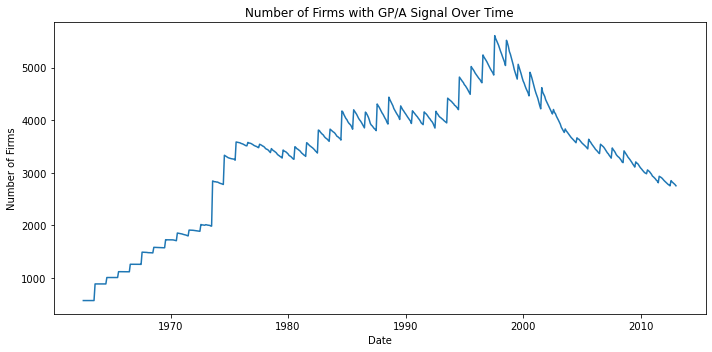

In [23]:
plt.figure(figsize=(10,5))
plt.plot(coverage_time['date'].to_numpy(), coverage_time['num_firms'].to_numpy())
plt.title("Number of Firms with GP/A Signal Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Firms")
plt.tight_layout()
plt.show()

### Cross-Sectional Descriptive Statistics

In [24]:
# Compute cross-sectional descriptive statistics of GP/A at each date,
# then summarize those statistics over time.
# This documents the distribution of the signal and checks for stability.

# Per-date cross-sectional stats
cs_stats = (
    merged.groupby('date')['gpa']
    .describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    .reset_index()
)

# Time-series average of each cross-sectional statistic
print("Time-series average of cross-sectional GP/A statistics:")
print(cs_stats.drop(columns='date').mean().to_frame('Mean over time').T.to_string())

# Also show overall full-sample stats
print("\nFull-sample GP/A descriptive statistics:")
print(merged['gpa'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

Time-series average of cross-sectional GP/A statistics:
                   count   mean    std     min    10%    25%    50%    75%    90%    max
Mean over time 3317.5578 0.3695 0.2856 -0.7430 0.0858 0.1896 0.3391 0.5119 0.7216 1.4229

Full-sample GP/A descriptive statistics:
count   2010440.0000
mean          0.3689
std           0.2987
min          -3.1762
1%           -0.4453
5%            0.0018
25%           0.1853
50%           0.3414
75%           0.5202
95%           0.8873
99%           1.2300
max           2.0869
Name: gpa, dtype: Float64


### Outlier and Stability Analysis

In [25]:
# Reload raw gpa before winsorization to show cutoffs
comp_check = pd.read_parquet("raw_compustat_funda_1961_2012.parquet")
comp_check = comp_check[(comp_check['sich'] < 6000) | (comp_check['sich'] >= 7000)]
comp_check = comp_check.dropna(subset=['revt', 'cogs', 'at'])
comp_check = comp_check[comp_check['at'] > 0]
comp_check['gpa'] = (comp_check['revt'] - comp_check['cogs']) / comp_check['at']
comp_check = comp_check.replace([np.inf, -np.inf], np.nan).dropna(subset=['gpa'])

# Winsorization cutoffs by year
cutoffs = comp_check.groupby('fyear')['gpa'].quantile([0.01, 0.99]).unstack()
cutoffs.columns = ['1st Pctile (lower bound)', '99th Pctile (upper bound)']
print("Winsorization cutoffs by fiscal year:")
print(cutoffs.tail(15).to_string())

Winsorization cutoffs by fiscal year:
       1st Pctile (lower bound)  99th Pctile (upper bound)
fyear                                                     
1998                    -1.3553                     1.6094
1999                    -1.4772                     1.4578
2000                    -2.4497                     1.5613
2001                    -3.2958                     1.9554
2002                    -3.1693                     2.1649
2003                    -1.9826                     1.9807
2004                    -1.4213                     1.6998
2005                    -1.3187                     1.6795
2006                    -1.5838                     1.5979
2007                    -1.5660                     1.5798
2008                    -2.4554                     1.7254
2009                    -1.8831                     1.8260
2010                    -1.1126                     1.8229
2011                    -2.2873                     1.7265
2012              

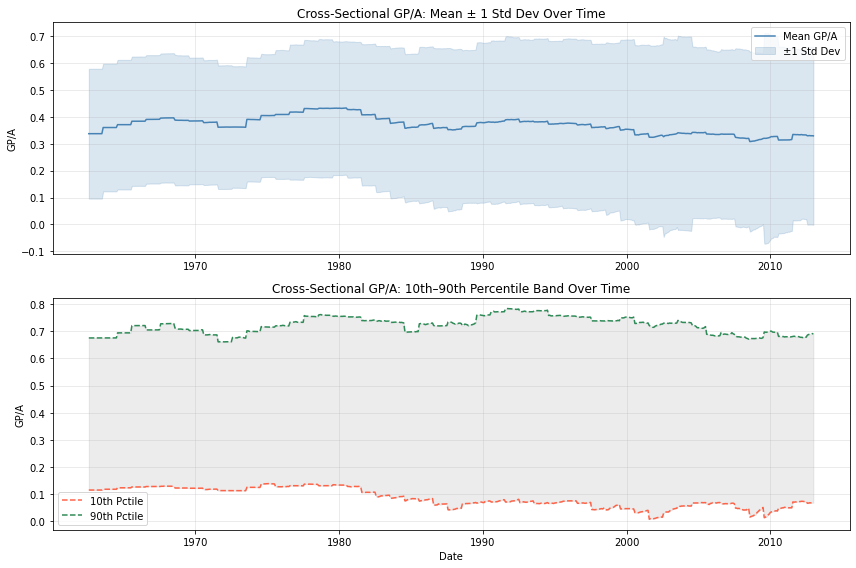

In [26]:
# Plot the time series of GP/A mean and standard deviation to check stability.
# Large shifts in the distribution over time could indicate data quality issues
# or structural changes in the sample composition.

cs_mean = merged.groupby('date')['gpa'].mean()
cs_std  = merged.groupby('date')['gpa'].std()
cs_p10  = merged.groupby('date')['gpa'].quantile(0.10)
cs_p90  = merged.groupby('date')['gpa'].quantile(0.90)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Panel 1: Mean ± 1 Std
axes[0].plot(cs_mean.index.to_numpy(), cs_mean.values.to_numpy(), label='Mean GP/A', color='steelblue')
axes[0].fill_between(cs_mean.index,
                     (cs_mean - cs_std).values,
                     (cs_mean + cs_std).values,
                     alpha=0.2, color='steelblue', label='±1 Std Dev')
axes[0].set_title('Cross-Sectional GP/A: Mean ± 1 Std Dev Over Time')
axes[0].set_ylabel('GP/A')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: 10th–90th percentile band
axes[1].plot(cs_p10.index.to_numpy(), cs_p10.values.to_numpy(), label='10th Pctile', color='tomato', linestyle='--')
axes[1].plot(cs_p90.index.to_numpy(), cs_p90.values.to_numpy(), label='90th Pctile', color='seagreen', linestyle='--')
axes[1].fill_between(cs_p10.index, cs_p10.values, cs_p90.values, alpha=0.15, color='gray')
axes[1].set_title('Cross-Sectional GP/A: 10th–90th Percentile Band Over Time')
axes[1].set_ylabel('GP/A')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Based on the plots, both the mean ± 1 std band and the 10th–90th percentile band remain broadly stable over time.

### Form Portfolios (Quintile Sort)

In [27]:
# Get June market equity

# Keep only June observations
june_me = merged[merged['date'].dt.month == 6].copy()

# Keep necessary variables
june_me = june_me[['permno', 'portfolio_year', 'me']]

# Rename for clarity
june_me = june_me.rename(columns={'me': 'me_june'})


# Merge June ME back into merged
merged = merged.merge(
    june_me,
    on=['permno', 'portfolio_year'],
    how='left'
)

Add B/M (For table 2 replication)

In [28]:
# Form quintiles using NYSE-only breakpoints, following Fama-French convention.
#
# Why NYSE breakpoints?
# Using all stocks (NYSE + AMEX + NASDAQ) would place most small NASDAQ stocks
# in the bottom quintile, distorting the portfolio composition. NYSE-only
# breakpoints spread stocks more evenly in terms of market cap.

# Step 1: Identify June observations
june_data = merged[merged['date'].dt.month == 6].copy()

# Step 2a: Compute NYSE-only breakpoints for GP/A
def nyse_quintile_assign_gpa(group):
    nyse_gpa = group[group['exchcd'] == 1]['gpa']
    if len(nyse_gpa) < 5: return pd.Series([np.nan] * len(group), index=group.index)
    breaks = nyse_gpa.quantile([0.2, 0.4, 0.6, 0.8]).values
    return pd.cut(group['gpa'], bins=[-np.inf, breaks[0], breaks[1], breaks[2], breaks[3], np.inf], labels=[1, 2, 3, 4, 5])

june_data['quintile'] = june_data.groupby('portfolio_year', group_keys=False).apply(nyse_quintile_assign_gpa)

# Step 2b: Compute NYSE-only breakpoints for Book-to-Market (B/M)
def nyse_quintile_assign_bm(group):
    nyse_bm = group[group['exchcd'] == 1]['bm']
    if len(nyse_bm) < 5: return pd.Series([np.nan] * len(group), index=group.index)
    breaks = nyse_bm.quantile([0.2, 0.4, 0.6, 0.8]).values
    return pd.cut(group['bm'], bins=[-np.inf, breaks[0], breaks[1], breaks[2], breaks[3], np.inf], labels=[1, 2, 3, 4, 5])

june_data['quintile_bm'] = june_data.groupby('portfolio_year', group_keys=False).apply(nyse_quintile_assign_bm)

# Step 3: Keep only identifiers and merge BOTH quintile assignments back
june_quintiles = june_data[['permno', 'portfolio_year', 'quintile', 'quintile_bm']]

merged = merged.merge(june_quintiles, on=['permno', 'portfolio_year'], how='left')

# Drop firms missing EITHER portfolio assignment
merged = merged.dropna(subset=['quintile', 'quintile_bm'])
merged = merged[merged['date'] >= '1963-07-01']

print("Quintile distribution:")
print(merged['quintile'].value_counts().sort_index())

/var/folders/mr/pbjp00px3gv04rs31k45rj740000gn/T/ipykernel_52714/918631547.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  june_data['quintile'] = june_data.groupby('portfolio_year', group_keys=False).apply(nyse_quintile_assign_gpa)
/var/folders/mr/pbjp00px3gv04rs31k45rj740000gn/T/ipykernel_52714/918631547.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  june_data['quintile_bm'] = june_data.groupby

Quintile distribution:
quintile
1    360480
2    300037
3    336368
4    385456
5    454766
Name: count, dtype: int64


In [29]:
print(merged.columns)

Index(['permno', 'date', 'ret', 'me', 'exchcd', 'gpa', 'portfolio_year', 'bm',
       'me_june', 'quintile', 'quintile_bm'],
      dtype='object')


In [30]:
# Remove firms without portfolio assignment
merged = merged.dropna(subset=['quintile'])

# Novy-Marx tests span July 1963 to Dec 2010. We will align our data filter.
merged = merged[(merged['date'] >= '1963-07-01') & (merged['date'] <= '2010-12-31')]

print("Sample period:", merged['date'].min().date(), "to", merged['date'].max().date())
print("Total observations:", merged.shape[0])

Sample period: 1963-07-31 to 2010-12-31
Total observations: 1789215


### Portfolio Return Calculation

In [31]:
# Calculate dynamic lagged market cap (ME from t-1) for value weighting
merged = merged.sort_values(['permno', 'date'])
merged['lag_me'] = merged.groupby('permno')['me'].shift(1)

# Fallback: If lag_me is missing (e.g., first month in portfolio), use current 'me'
# or me_june as a proxy to prevent dropping valid return observations
merged['weight'] = merged['lag_me'].fillna(merged['me_june'])

# Remove firms with missing weights or returns
merged = merged.dropna(subset=['weight', 'ret'])
# Ensure weights are strictly positive
merged = merged[merged['weight'] > 0]

# --- Value-Weighted Returns ---
# Using the dynamic 1-month lagged weight
def wavg(group):
    d = group['ret']
    w = group['weight']
    return (d * w).sum() / w.sum()

vw_returns = (
    merged
    .groupby(['date', 'quintile'])
    .apply(wavg, include_groups=False)
    .reset_index(name='vw_ret')
)

# --- Equal-Weighted Returns ---
# Each stock receives equal weight within the portfolio each month
ew_returns = (
    merged
    .groupby(['date', 'quintile'])['ret']
    .mean()
    .reset_index(name='ew_ret')
)

print("VW returns shape:", vw_returns.shape)
print("EW returns shape:", ew_returns.shape)
print(vw_returns.head(10))

/var/folders/mr/pbjp00px3gv04rs31k45rj740000gn/T/ipykernel_52714/1866067407.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged


VW returns shape: (2850, 3)
EW returns shape: (2850, 3)
        date quintile  vw_ret
0 1963-07-31        1  0.0068
1 1963-07-31        2  0.0089
2 1963-07-31        3 -0.0154
3 1963-07-31        4  0.0019
4 1963-07-31        5  0.0067
5 1963-08-30        1  0.0496
6 1963-08-30        2  0.0392
7 1963-08-30        3  0.0606
8 1963-08-30        4  0.0585
9 1963-08-30        5  0.0659


/var/folders/mr/pbjp00px3gv04rs31k45rj740000gn/T/ipykernel_52714/1866067407.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged


Add B/M (For table 2 replication)

In [32]:
# --- Value-Weighted Returns for B/M ---
vw_returns_bm = (
    merged
    .groupby(['date', 'quintile_bm'])
    .apply(wavg, include_groups=False)
    .reset_index(name='vw_ret')
)

pivot_vw_bm = vw_returns_bm.pivot(index='date', columns='quintile_bm', values='vw_ret')
pivot_vw_bm = pivot_vw_bm.dropna(subset=[1, 5])

# B/M Long-Short: High B/M (Value, Q5) minus Low B/M (Growth, Q1)
pivot_vw_bm['HML_BM'] = pivot_vw_bm[5] - pivot_vw_bm[1]  
portfolio_returns_vw_bm = pivot_vw_bm.reset_index()

print("B/M VW Portfolio months:", len(portfolio_returns_vw_bm))

/var/folders/mr/pbjp00px3gv04rs31k45rj740000gn/T/ipykernel_52714/2935452885.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged


B/M VW Portfolio months: 570


### Long-Short Portfolio Performance

In [33]:
# --- Value-Weighted ---
pivot_vw = vw_returns.pivot(index='date', columns='quintile', values='vw_ret')
pivot_vw = pivot_vw.dropna(subset=[1, 5])
pivot_vw['HML_GP'] = pivot_vw[5] - pivot_vw[1]  # Q5 (high GP/A) - Q1 (low GP/A)

# --- Equal-Weighted ---
pivot_ew = ew_returns.pivot(index='date', columns='quintile', values='ew_ret')
pivot_ew = pivot_ew.dropna(subset=[1, 5])
pivot_ew['HML_GP'] = pivot_ew[5] - pivot_ew[1]

portfolio_returns_vw = pivot_vw.reset_index()
portfolio_returns_ew = pivot_ew.reset_index()

print("=== Value-Weighted ===")
print("Portfolio months:", len(portfolio_returns_vw))
print("Mean HML_GP (VW):", round(portfolio_returns_vw['HML_GP'].mean() * 100, 4), "% / month")

print("\n=== Equal-Weighted ===")
print("Portfolio months:", len(portfolio_returns_ew))
print("Mean HML_GP (EW):", round(portfolio_returns_ew['HML_GP'].mean() * 100, 4), "% / month")

=== Value-Weighted ===
Portfolio months: 570
Mean HML_GP (VW): 0.3008 % / month

=== Equal-Weighted ===
Portfolio months: 570
Mean HML_GP (EW): 0.3852 % / month


### Compute Summary Statistics and t-Stats (Replicate Table 2)

In [34]:
ff = ff_factors.copy()
ff['date'] = pd.to_datetime(ff['date'])

# Create year-month identifier for merging
portfolio_returns_vw['ym'] = portfolio_returns_vw['date'].dt.to_period('M')
portfolio_returns_ew['ym'] = portfolio_returns_ew['date'].dt.to_period('M')
ff['ym'] = ff['date'].dt.to_period('M')

# Merge VW and EW portfolios with FF factors
data_vw = portfolio_returns_vw.merge(ff, on='ym', how='inner')
data_ew = portfolio_returns_ew.merge(ff, on='ym', how='inner')

print("VW data rows:", len(data_vw))
print("EW data rows:", len(data_ew))

VW data rows: 570
EW data rows: 570


In [35]:
def run_regressions(data, dep_var='HML_GP', is_long_short=True, label='VW'):
    """
    Run raw mean, CAPM, and FF3 regressions on a portfolio.
    Uses Newey-West HAC standard errors (4 lags) as required in empirical
    asset pricing to account for autocorrelation in monthly returns.
    """
    # Dynamically select columns to avoid hardcoding HML_GP
    cols_to_keep = ['ym', dep_var, 'rf', 'mktrf', 'smb', 'hml']
    reg = data[cols_to_keep].copy()
    
    for col in [dep_var, 'rf', 'mktrf', 'smb', 'hml']:
        reg[col] = pd.to_numeric(reg[col], errors='coerce')

    # Handle Excess Return Calculation
    if is_long_short:
        # Risk-free rate cancels out for zero-investment portfolios
        reg['excess_ret'] = reg[dep_var]
        port_type = "Long-Short"
    else:
        # Subtract risk-free rate for standard long-only portfolios
        reg['excess_ret'] = reg[dep_var] - reg['rf']
        port_type = "Long-Only"

    print(f"\n{'='*50}")
    print(f"  {label} {port_type} ({dep_var}) Regressions")
    print(f"{'='*50}")
    print(f"Observations: {len(reg)}")

    # 1. Mean excess return (Newey-West)
    raw_model = sm.OLS(reg['excess_ret'], np.ones(len(reg))).fit(
        cov_type='HAC', cov_kwds={'maxlags': 4}
    )
    print(f"\nMean excess return: {raw_model.params.iloc[0]*100:.4f}% per month")
    print(f"t-stat (NW):        {raw_model.tvalues.iloc[0]:.2f}")

    # 2. CAPM alpha (Newey-West)
    X_capm = sm.add_constant(reg[['mktrf']].astype(float))
    capm = sm.OLS(reg['excess_ret'], X_capm).fit(
        cov_type='HAC', cov_kwds={'maxlags': 4}
    )
    print(f"\nCAPM alpha:       {capm.params['const']*100:.4f}% per month")
    print(f"t-stat (NW):      {capm.tvalues['const']:.2f}")
    print(f"MKT beta:         {capm.params['mktrf']:.4f}")

    # 3. FF3 alpha (Newey-West)
    X_ff3 = sm.add_constant(reg[['mktrf', 'smb', 'hml']].astype(float))
    ff3 = sm.OLS(reg['excess_ret'], X_ff3).fit(
        cov_type='HAC', cov_kwds={'maxlags': 4}
    )
    
    print(f"\nFF3 alpha:        {ff3.params['const']*100:.4f}% per month")
    print(f"t-stat (NW):      {ff3.tvalues['const']:.2f}")
    print(f"MKT beta:         {ff3.params['mktrf']:.4f}")
    print(f"MKT t-stat:       {ff3.tvalues['mktrf']:.4f}")
    print(f"SMB beta:         {ff3.params['smb']:.4f}")
    print(f"SMB t-stat:       {ff3.tvalues['smb']:.4f}")
    print(f"HML beta:         {ff3.params['hml']:.4f}")
    print(f"HML t-stat:       {ff3.tvalues['hml']:.4f}")

    return reg

reg_vw_spread = run_regressions(data_vw, dep_var='HML_GP', is_long_short=True, label='Value-Weighted')


  Value-Weighted Long-Short (HML_GP) Regressions
Observations: 570

Mean excess return: 0.3008% per month
t-stat (NW):        2.19

CAPM alpha:       0.2787% per month
t-stat (NW):      1.99
MKT beta:         0.0492

FF3 alpha:        0.5181% per month
t-stat (NW):      4.25
MKT beta:         -0.0246
MKT t-stat:       -0.6989
SMB beta:         -0.0563
SMB t-stat:       -1.1751
HML beta:         -0.4778
HML t-stat:       -6.5568


In [36]:
reg_vw_q5 = run_regressions(data_vw, dep_var=5, is_long_short=False, label='Value-Weighted Q5')


  Value-Weighted Q5 Long-Only (5) Regressions
Observations: 570

Mean excess return: 0.6000% per month
t-stat (NW):        2.85

CAPM alpha:       0.1698% per month
t-stat (NW):      2.05
MKT beta:         0.9601

FF3 alpha:        0.3142% per month
t-stat (NW):      4.21
MKT beta:         0.9180
MKT t-stat:       41.7105
SMB beta:         -0.0433
SMB t-stat:       -1.5687
HML beta:         -0.2853
HML t-stat:       -6.8282


In [37]:
reg_vw_q4 = run_regressions(data_vw, dep_var=4, is_long_short=False, label='Value-Weighted Q4')


  Value-Weighted Q4 Long-Only (4) Regressions
Observations: 570

Mean excess return: 0.3966% per month
t-stat (NW):        1.81

CAPM alpha:       -0.0806% per month
t-stat (NW):      -1.19
MKT beta:         1.0648

FF3 alpha:        0.0258% per month
t-stat (NW):      0.40
MKT beta:         1.0178
MKT t-stat:       52.6261
SMB beta:         0.0295
SMB t-stat:       0.9059
HML beta:         -0.2295
HML t-stat:       -6.3185


In [38]:
reg_vw_q3 = run_regressions(data_vw, dep_var=3, is_long_short=False, label='Value-Weighted Q3')


  Value-Weighted Q3 Long-Only (3) Regressions
Observations: 570

Mean excess return: 0.4697% per month
t-stat (NW):        2.30

CAPM alpha:       0.0140% per month
t-stat (NW):      0.23
MKT beta:         1.0169

FF3 alpha:        -0.0122% per month
t-stat (NW):      -0.19
MKT beta:         1.0170
MKT t-stat:       50.6900
SMB beta:         0.0369
SMB t-stat:       1.2241
HML beta:         0.0427
HML t-stat:       1.1232


In [39]:
reg_vw_q2 = run_regressions(data_vw, dep_var=2, is_long_short=False, label='Value-Weighted Q2')


  Value-Weighted Q2 Long-Only (2) Regressions
Observations: 570

Mean excess return: 0.3606% per month
t-stat (NW):        1.77

CAPM alpha:       -0.0694% per month
t-stat (NW):      -0.85
MKT beta:         0.9596

FF3 alpha:        -0.1334% per month
t-stat (NW):      -1.71
MKT beta:         1.0069
MKT t-stat:       40.1735
SMB beta:         -0.0917
SMB t-stat:       -2.4618
HML beta:         0.1614
HML t-stat:       3.8060


In [40]:
reg_vw_q1 = run_regressions(data_vw, dep_var=1, is_long_short=False, label='Value-Weighted Q1')


  Value-Weighted Q1 Long-Only (1) Regressions
Observations: 570

Mean excess return: 0.2992% per month
t-stat (NW):        1.49

CAPM alpha:       -0.1090% per month
t-stat (NW):      -1.38
MKT beta:         0.9109

FF3 alpha:        -0.2039% per month
t-stat (NW):      -2.81
MKT beta:         0.9426
MKT t-stat:       48.0761
SMB beta:         0.0130
SMB t-stat:       0.4162
HML beta:         0.1925
HML t-stat:       4.4771


In [41]:
reg_ew_spread = run_regressions(data_ew, dep_var='HML_GP', is_long_short=True, label='Equal-Weighted')


  Equal-Weighted Long-Short (HML_GP) Regressions
Observations: 570

Mean excess return: 0.3852% per month
t-stat (NW):        3.01

CAPM alpha:       0.3652% per month
t-stat (NW):      2.79
MKT beta:         0.0446

FF3 alpha:        0.3661% per month
t-stat (NW):      2.93
MKT beta:         0.0189
MKT t-stat:       0.5020
SMB beta:         0.0982
SMB t-stat:       1.0816
HML beta:         -0.0328
HML t-stat:       -0.4867


The VW long-short portfolio generates a statistically significant mean excess return of 0.30% per month (t=2.19), consistent with the profitability premium documented in Novy-Marx (2013). Alphas are significant after FF3 adjustment, suggesting the premium is not explained by common risk factors. The negative HML beta (-0.48 for VW) confirms that high GP/A firms are growth-oriented, consistent with the paper's finding that profitability is a growth strategy.

Add B/M (For table 2 replication)

In [42]:
portfolio_returns_vw_bm['ym'] = portfolio_returns_vw['date'].dt.to_period('M')
bm_data_vw = portfolio_returns_vw_bm.merge(ff, on='ym', how='inner')

# Run the regressions for the Long-Short Spread (H-L)
reg_vw_bm_spread = run_regressions(
    data=bm_data_vw, 
    dep_var='HML_BM', 
    is_long_short=True, 
    label='Value-Weighted B/M'
)


  Value-Weighted B/M Long-Short (HML_BM) Regressions
Observations: 570

Mean excess return: 0.3590% per month
t-stat (NW):        2.18

CAPM alpha:       0.4114% per month
t-stat (NW):      2.47
MKT beta:         -0.1171

FF3 alpha:        -0.1871% per month
t-stat (NW):      -2.21
MKT beta:         0.0136
MKT t-stat:       0.4713
SMB beta:         0.3491
SMB t-stat:       10.0130
HML beta:         1.1290
HML t-stat:       21.9429


In [43]:
reg_vw_bm_q1 = run_regressions(
    data=bm_data_vw, 
    dep_var=1, 
    is_long_short=False,
    label='Value-Weighted B/M Q1'
)


  Value-Weighted B/M Q1 Long-Only (1) Regressions
Observations: 570

Mean excess return: 0.3808% per month
t-stat (NW):        1.70

CAPM alpha:       -0.0910% per month
t-stat (NW):      -1.25
MKT beta:         1.0529

FF3 alpha:        0.1254% per month
t-stat (NW):      2.75
MKT beta:         0.9971
MKT t-stat:       73.0346
SMB beta:         -0.0930
SMB t-stat:       -4.6054
HML beta:         -0.4186
HML t-stat:       -17.4901


In [44]:
reg_vw_bm_q2 = run_regressions(
    data=bm_data_vw, 
    dep_var=2, 
    is_long_short=False,
    label='Value-Weighted B/M Q2'
)


  Value-Weighted B/M Q2 Long-Only (2) Regressions
Observations: 570

Mean excess return: 0.4293% per month
t-stat (NW):        2.12

CAPM alpha:       -0.0137% per month
t-stat (NW):      -0.22
MKT beta:         0.9886

FF3 alpha:        -0.0349% per month
t-stat (NW):      -0.57
MKT beta:         0.9878
MKT t-stat:       50.7613
SMB beta:         0.0332
SMB t-stat:       1.2197
HML beta:         0.0333
HML t-stat:       0.7587


In [45]:
reg_vw_bm_q3 = run_regressions(
    data=bm_data_vw, 
    dep_var=3, 
    is_long_short=False,
    label='Value-Weighted B/M Q3'
)


  Value-Weighted B/M Q3 Long-Only (3) Regressions
Observations: 570

Mean excess return: 0.4694% per month
t-stat (NW):        2.51

CAPM alpha:       0.0592% per month
t-stat (NW):      0.77
MKT beta:         0.9155

FF3 alpha:        -0.0321% per month
t-stat (NW):      -0.45
MKT beta:         0.9466
MKT t-stat:       41.2538
SMB beta:         0.0100
SMB t-stat:       0.2817
HML beta:         0.1858
HML t-stat:       3.8812


In [46]:
reg_vw_bm_q4 = run_regressions(
    data=bm_data_vw, 
    dep_var=4, 
    is_long_short=False, 
    label='Value-Weighted B/M Q4'
)


  Value-Weighted B/M Q4 Long-Only (4) Regressions
Observations: 570

Mean excess return: 0.6326% per month
t-stat (NW):        3.31

CAPM alpha:       0.2456% per month
t-stat (NW):      2.68
MKT beta:         0.8636

FF3 alpha:        0.0037% per month
t-stat (NW):      0.05
MKT beta:         0.9276
MKT t-stat:       47.9376
SMB beta:         0.0980
SMB t-stat:       3.0582
HML beta:         0.4700
HML t-stat:       10.7397


In [47]:
reg_vw_bm_q5 = run_regressions(
    data=bm_data_vw, 
    dep_var=5, 
    is_long_short=False, 
    label='Value-Weighted B/M Q5'
)


  Value-Weighted B/M Q5 Long-Only (5) Regressions
Observations: 570

Mean excess return: 0.7398% per month
t-stat (NW):        3.44

CAPM alpha:       0.3205% per month
t-stat (NW):      2.86
MKT beta:         0.9359

FF3 alpha:        -0.0617% per month
t-stat (NW):      -0.87
MKT beta:         1.0107
MKT t-stat:       41.2565
SMB beta:         0.2561
SMB t-stat:       8.6447
HML beta:         0.7104
HML t-stat:       16.0378


By reconstructing Table 2, Panel B (portfolios by B/M), we found that our replicated value premium metrics align with the paper's benchmarks. This also acts like a robustness check, confirming that our universe construction and backtesting methodologies are accurate.

### Risk-Adjusted Performance Metrics

In [48]:
# Compute key risk-adjusted metrics for all quintiles and HML_GP
# for both value-weighted and equal-weighted portfolios.

def compute_metrics(pivot_df, ff_df, weighting='VW'):
    """Compute annualized return, vol, Sharpe, and max drawdown by quintile."""
    # Build a clean rf series from ff_df (ym may not exist yet on ff_df)
    ff_df2 = ff_df[['date', 'rf']].copy()
    ff_df2['ym'] = ff_df2['date'].dt.to_period('M')
    ff_df2 = ff_df2[['ym', 'rf']]

    temp = pivot_df.copy()
    temp['ym'] = temp['date'].dt.to_period('M')
    temp = temp.merge(ff_df2, on='ym', how='inner')
    temp['rf'] = pd.to_numeric(temp['rf'], errors='coerce')

    cols = [1, 2, 3, 4, 5, 'HML_GP']
    results = []
    for col in cols:
        if col not in temp.columns:
            continue
        r = pd.to_numeric(temp[col], errors='coerce').dropna()
        rf = temp.loc[r.index, 'rf']
        if col == 'HML_GP':
            excess = r  # Risk-free rate already differenced out
        else:
            excess = r - rf
        ann_ret  = r.mean() * 12
        ann_vol  = r.std() * np.sqrt(12)
        sharpe   = excess.mean() / excess.std() * np.sqrt(12)
        # Max drawdown
        cum = (1 + r).cumprod()
        roll_max = cum.cummax()
        drawdown = (cum - roll_max) / roll_max
        max_dd   = drawdown.min()
        results.append({
            'Portfolio': f'Q{col}' if isinstance(col, int) else col,
            'Ann. Return (%)': round(ann_ret * 100, 2),
            'Ann. Vol (%)':    round(ann_vol * 100, 2),
            'Sharpe Ratio':    round(sharpe, 3),
            'Max Drawdown (%)':round(max_dd * 100, 2),
        })
    df = pd.DataFrame(results)
    print(f"=== {weighting} Portfolio Metrics ===")
    print(df.to_string(index=False))
    return df

metrics_vw = compute_metrics(portfolio_returns_vw, ff_factors, 'Value-Weighted')
metrics_ew = compute_metrics(portfolio_returns_ew, ff_factors, 'Equal-Weighted')


=== Value-Weighted Portfolio Metrics ===
Portfolio  Ann. Return (%)  Ann. Vol (%)  Sharpe Ratio  Max Drawdown (%)
       Q1           8.8900       15.5200        0.2310          -61.3000
       Q2           9.6200       16.1800        0.2670          -56.1300
       Q3          10.9300       16.6800        0.3370          -52.4600
       Q4          10.0600       17.6100        0.2700          -53.2200
       Q5          12.5000       16.2700        0.4410          -51.8600
   HML_GP           3.6100       10.5800        0.3410          -57.9100
=== Equal-Weighted Portfolio Metrics ===
Portfolio  Ann. Return (%)  Ann. Vol (%)  Sharpe Ratio  Max Drawdown (%)
       Q1          13.7000       21.9800        0.3810          -60.9700
       Q2          14.4600       21.3700        0.4270          -61.1400
       Q3          15.5300       21.6700        0.4700          -58.4100
       Q4          16.2300       21.9800        0.4960          -62.6400
       Q5          18.3200       21.7000  

Quintile 5 has the highest Sharpe ratios across both weighting schemes, 0.44 for value-weighted and 0.60 for equal-weighted. While individual quintiles suffer maximum drawdowns exceeding 50%, the H-L strategy successfully generates positive annualized returns while dampening overall portfolio volatility down to around 9 to 10%.

### Cumulative Returns Over Full Backtesting Period

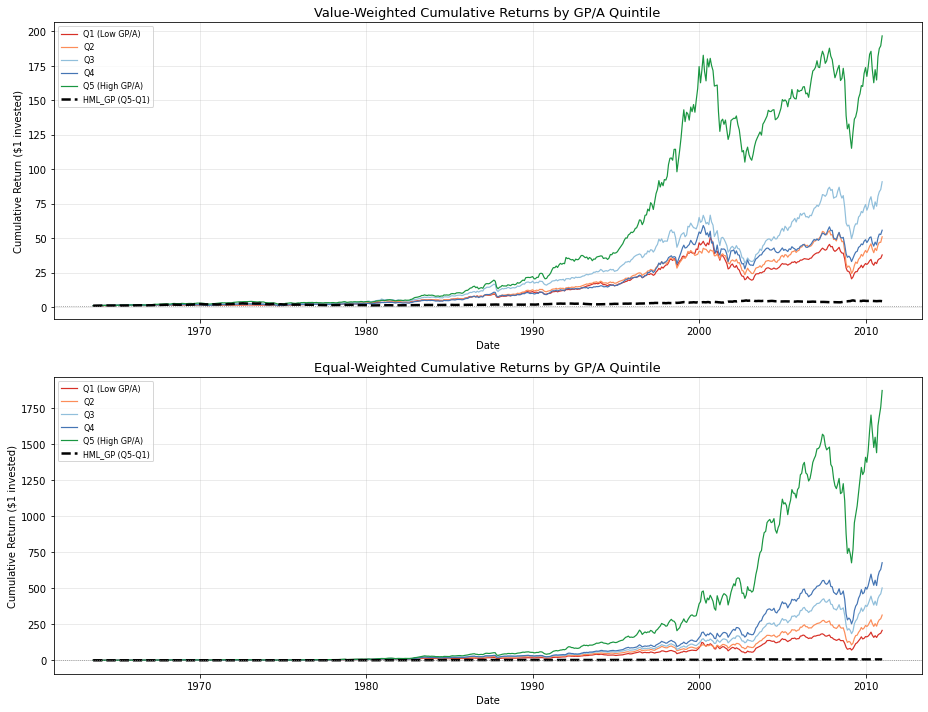

In [49]:
# Cumulative return plot for all quintile portfolios and HML_GP
# A $1 investment at the start of the sample, held through the end.

fig, axes = plt.subplots(2, 1, figsize=(13, 10))
colors = ['#d73027', '#fc8d59', '#91bfdb', '#4575b4', '#1a9641', 'black']
labels = ['Q1 (Low GP/A)', 'Q2', 'Q3', 'Q4', 'Q5 (High GP/A)', 'HML_GP (Q5-Q1)']
styles = ['-', '-', '-', '-', '-', '--']
widths = [1.2, 1.2, 1.2, 1.2, 1.2, 2.5]

for ax, pivot_df, title in zip(
    axes,
    [portfolio_returns_vw, portfolio_returns_ew],
    ['Value-Weighted Cumulative Returns by GP/A Quintile',
     'Equal-Weighted Cumulative Returns by GP/A Quintile']
):
    temp = pivot_df.copy()
    for col, color, label, ls, lw in zip(
        [1, 2, 3, 4, 5, 'HML_GP'], colors, labels, styles, widths
    ):
        if col not in temp.columns:
            continue
        cum = (1 + pd.to_numeric(temp[col], errors='coerce').fillna(0)).cumprod()
        ax.plot(temp['date'].values, cum.values,
                label=label, color=color, linestyle=ls, linewidth=lw)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Cumulative Return ($1 invested)')
    ax.set_xlabel('Date')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=1, color='gray', linestyle=':', linewidth=0.8)

plt.tight_layout()
plt.show()

Q5, the highest-profitability group, consistently outperforms Q1 in both the value-weighted and equal-weighted portfolios. The difference is especially strong under equal weighting. For example, in the equal-weighted portfolios, Q5 grows to roughly 1,800 times the initial investment, while Q1 grows to only about 200 times. The gap widens noticeably after the 1990s, suggesting that the profitability premium is stronger among smaller firms, since equal-weighted portfolios put relatively more weight on small-cap stocks.

### Portfolio Characteristics Table

In [50]:
print(type(portfolio_returns_vw))
print(portfolio_returns_vw.columns.tolist())
print(portfolio_returns_vw.index[:3])
print(data_vw.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
['date', 1, 2, 3, 4, 5, 'HML_GP', 'ym']
RangeIndex(start=0, stop=3, step=1)
['date_x', 1, 2, 3, 4, 5, 'HML_GP', 'ym', 'date_y', 'mktrf', 'smb', 'hml', 'umd', 'rf']


In [51]:
# Replicate the portfolio characteristics table from Novy-Marx (2013) Table 2.
# For each GP/A quintile, report:
#   - Average monthly excess return and t-stat
#   - FF3 alpha and t-stat
#   - Average GP/A, average ME (in millions), average number of firms

from scipy import stats as scipy_stats

def portfolio_char_table(pivot_df, merged_df, data_ff, weighting='VW'):

    # Fix column names — quintile cols may be float (1.0) or int (1)
    pivot_df = pivot_df.copy()
    rename_map = {c: int(c) for c in pivot_df.columns if isinstance(c, float)}
    pivot_df = pivot_df.rename(columns=rename_map)

    # Ensure date is a column
    if 'date' not in pivot_df.columns:
        pivot_df = pivot_df.reset_index()

    # data_ff may have date_x instead of date due to merge conflict
    ff_reg = data_ff.copy()
    if 'date' not in ff_reg.columns:
        ff_reg = ff_reg.rename(columns={'date_x': 'date'})
    ff_reg = ff_reg[['date','rf','mktrf','smb','hml']].copy()
    for col in ['rf', 'mktrf', 'smb', 'hml']:
        ff_reg[col] = pd.to_numeric(ff_reg[col], errors='coerce')
    ff_reg = ff_reg.dropna(subset=['rf','mktrf','smb','hml'])
    ff_reg = ff_reg.set_index('date')

    temp = pivot_df.set_index('date')

    firm_chars = (
        merged_df
        .groupby(['date','quintile'])
        .agg(avg_gpa=('gpa','mean'), avg_me=('me','mean'), n_firms=('permno','nunique'))
        .groupby('quintile').mean().reset_index()
    )

    rows = []
    for q in [1, 2, 3, 4, 5, 'HML_GP']:
        if q not in temp.columns:
            continue

        r = pd.to_numeric(temp[q], errors='coerce').dropna()
        rf = ff_reg['rf'].reindex(r.index).dropna()
        r  = r.reindex(rf.index)

        model_mean = sm.OLS(r.values, np.ones(len(r))).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
        mean_ret = model_mean.params[0]
        t_mean   = model_mean.tvalues[0]

        reg_ff   = ff_reg[['mktrf','smb','hml']].reindex(r.index).dropna()
        if q == 'HML_GP':
            excess_r = r.reindex(reg_ff.index).values.astype(float)
        else:
            excess_r = (r.reindex(reg_ff.index) - ff_reg['rf'].reindex(reg_ff.index))
            excess_r = pd.to_numeric(excess_r, errors='coerce').values.astype(float)
        X        = sm.add_constant(reg_ff.astype(float).values)
        ff3_model = sm.OLS(excess_r, X).fit(cov_type='HAC', cov_kwds={'maxlags': 4})
        alpha    = ff3_model.params[0]
        t_alpha  = ff3_model.tvalues[0]

        if isinstance(q, int):
            chars   = firm_chars[firm_chars['quintile'] == q]
            avg_gpa = chars['avg_gpa'].values[0] if len(chars) else np.nan
            avg_me  = chars['avg_me'].values[0]  if len(chars) else np.nan
            n_firms = chars['n_firms'].values[0] if len(chars) else np.nan
            # Avg B/M: compute from merged_df directly, allow NaN
            bm_q = merged_df[merged_df['quintile'] == q]['bm']
            avg_bm = bm_q.mean() if 'bm' in merged_df.columns else np.nan
        else:
            avg_gpa = avg_me = n_firms = avg_bm = np.nan

        rows.append({
            'Portfolio'           : f'Q{q}' if isinstance(q, int) else q,
            'Avg Ret (% per mo)'  : round(mean_ret * 100, 3),
            't-stat'              : round(t_mean, 2),
            'FF3 Alpha (% per mo)': round(alpha * 100, 3),
            't-stat (alpha)'      : round(t_alpha, 2),
            'Avg GP/A'            : round(avg_gpa, 3) if not np.isnan(avg_gpa) else '-',
            'Avg B/M'             : round(avg_bm, 3) if (not np.isnan(avg_bm) if isinstance(avg_bm, float) else False) else '-',
            'Avg ME ($M)'         : round(avg_me / 1e3, 0) if not np.isnan(avg_me) else '-',
            'Avg # Firms'         : round(n_firms, 0) if not np.isnan(n_firms) else '-',
        })

    df = pd.DataFrame(rows)
    print(f"\n=== {weighting} Portfolio Characteristics Table ===")
    print(df.to_string(index=False))
    return df

char_table_vw = portfolio_char_table(portfolio_returns_vw, merged, data_vw, weighting='VW')
char_table_ew = portfolio_char_table(portfolio_returns_ew, merged, data_ew, weighting='EW')

/var/folders/mr/pbjp00px3gv04rs31k45rj740000gn/T/ipykernel_52714/2968951680.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df
/var/folders/mr/pbjp00px3gv04rs31k45rj740000gn/T/ipykernel_52714/2968951680.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df



=== VW Portfolio Characteristics Table ===
Portfolio  Avg Ret (% per mo)  t-stat  FF3 Alpha (% per mo)  t-stat (alpha) Avg GP/A Avg B/M Avg ME ($M) Avg # Firms
       Q1              0.7410  3.6900               -0.2040         -2.8100   0.0420  0.9880    918.0000    615.0000
       Q2              0.8020  3.9600               -0.1330         -1.7100   0.2110  1.0490   1229.0000    514.0000
       Q3              0.9110  4.4900               -0.0120         -0.1900   0.3170  0.9420   1168.0000    574.0000
       Q4              0.8380  3.8600                0.0260          0.4000   0.4410  0.8370   1284.0000    656.0000
       Q5              1.0410  4.9700                0.3140          4.2100   0.7420  0.7330   1260.0000    776.0000
   HML_GP              0.3010  2.1900                0.5180          4.2500        -       -           -           -


/var/folders/mr/pbjp00px3gv04rs31k45rj740000gn/T/ipykernel_52714/2968951680.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df
/var/folders/mr/pbjp00px3gv04rs31k45rj740000gn/T/ipykernel_52714/2968951680.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged_df



=== EW Portfolio Characteristics Table ===
Portfolio  Avg Ret (% per mo)  t-stat  FF3 Alpha (% per mo)  t-stat (alpha) Avg GP/A Avg B/M Avg ME ($M) Avg # Firms
       Q1              1.1420  3.7800               -0.0060         -0.0400   0.0420  0.9880    918.0000    615.0000
       Q2              1.2050  4.1500               -0.0680         -0.8000   0.2110  1.0490   1229.0000    514.0000
       Q3              1.2940  4.3500                0.0430          0.5900   0.3170  0.9420   1168.0000    574.0000
       Q4              1.3530  4.4900                0.1370          1.9100   0.4410  0.8370   1284.0000    656.0000
       Q5              1.5270  5.0500                0.3610          4.5900   0.7420  0.7330   1260.0000    776.0000
   HML_GP              0.3850  3.0100                0.3660          2.9300        -       -           -           -


GP/A increases monotonically from Q1 (0.042) to Q5 (0.742), confirming the quintile sort is correctly ordered. Average returns also increase monotonically from Q1 to Q5 for both VW and EW portfolios. This monotonic pattern strongly supports the existence of a gross profitability premium in our sample period.

The VW long-short spread (0.30% per month) is positive and significant after risk adjustment. The EW spread (0.39% per month, t=3.01) is also significant at the 5% level on a raw basis. 

### Formal Significance Tests — Long-Short Portfolio

In [52]:
# Formal statistical significance tests for the long-short HML_GP portfolio.
# Reports raw mean, CAPM alpha, and FF3 alpha with Newey-West t-stats
# for both VW and EW, presented as a clean summary table.

def significance_table(reg_data, label='VW'):
    """
    Run three specifications and collect results into a single summary table.
    Specifications:
      (1) Raw mean (no risk adjustment)
      (2) CAPM alpha
      (3) FF3 alpha
    """
    reg = reg_data.copy()
    

    rows = []

    # (1) Raw mean
    m = sm.OLS(reg['HML_GP'], np.ones(len(reg))).fit(
        cov_type='HAC', cov_kwds={'maxlags': 4}
    )
    rows.append({
        'Specification'  : '(1) Raw Mean',
        'Estimate (%/mo)': round(m.params.iloc[0]*100, 4),
        't-stat'         : round(m.tvalues.iloc[0], 2),
        'Significant'    : 'Yes' if abs(m.tvalues.iloc[0]) > 1.96 else 'No',
    })

    # (2) CAPM alpha
    X = sm.add_constant(reg[['mktrf']].astype(float))
    m = sm.OLS(reg['HML_GP'], X).fit(
        cov_type='HAC', cov_kwds={'maxlags': 4}
    )
    rows.append({
        'Specification'  : '(2) CAPM Alpha',
        'Estimate (%/mo)': round(m.params['const']*100, 4),
        't-stat'         : round(m.tvalues['const'], 2),
        'Significant'    : 'Yes' if abs(m.tvalues['const']) > 1.96 else 'No',
    })

    # (3) FF3 alpha
    X = sm.add_constant(reg[['mktrf','smb','hml']].astype(float))
    m = sm.OLS(reg['HML_GP'], X).fit(
        cov_type='HAC', cov_kwds={'maxlags': 4}
    )
    rows.append({
        'Specification'  : '(3) FF3 Alpha',
        'Estimate (%/mo)': round(m.params['const']*100, 4),
        't-stat'         : round(m.tvalues['const'], 2),
        'Significant'    : 'Yes' if abs(m.tvalues['const']) > 1.96 else 'No',
    })

    df = pd.DataFrame(rows)
    print(f"\n=== Significance Tests: HML_GP Long-Short ({label}) ===")
    print(df.to_string(index=False))
    print("Note: t-statistics computed with Newey-West HAC standard errors (4 lags).")
    print("      Significance threshold: |t| > 1.96 (5% level, two-tailed).")
    return df

sig_vw = significance_table(reg_vw_spread, label='Value-Weighted')
sig_ew = significance_table(reg_ew_spread, label='Equal-Weighted')


=== Significance Tests: HML_GP Long-Short (Value-Weighted) ===
 Specification  Estimate (%/mo)  t-stat Significant
  (1) Raw Mean           0.3008  2.1900         Yes
(2) CAPM Alpha           0.2787  1.9900         Yes
 (3) FF3 Alpha           0.5181  4.2500         Yes
Note: t-statistics computed with Newey-West HAC standard errors (4 lags).
      Significance threshold: |t| > 1.96 (5% level, two-tailed).

=== Significance Tests: HML_GP Long-Short (Equal-Weighted) ===
 Specification  Estimate (%/mo)  t-stat Significant
  (1) Raw Mean           0.3852  3.0100         Yes
(2) CAPM Alpha           0.3652  2.7900         Yes
 (3) FF3 Alpha           0.3661  2.9300         Yes
Note: t-statistics computed with Newey-West HAC standard errors (4 lags).
      Significance threshold: |t| > 1.96 (5% level, two-tailed).


On a value-weighted basis, all three specifications are statistically significant. The FF3 alpha is 0.52% per month with a t-stat of 4.25 and matches the paper's reported FF3 alpha of 0.52% at t = 4.49. The HML loading is -0.48, confirming that high gross profitability firms are growth-oriented, and the alpha is unexplained by the three-factor model. Overall, the gross profitability premium survives risk adjustment and is shown to be an independent signal from market, size, or value.

Add B/M (For table 2 replication)

In [53]:
# Format the B/M data to run through your existing regression function
reg_vw_bm = portfolio_returns_vw_bm.copy()
reg_vw_bm['ym'] = reg_vw_bm['date'].dt.to_period('M')

# Merge with Fama-French factors
# Note: Use your previously loaded ff_factors dataframe
ff_temp = ff_factors.copy()
ff_temp['ym'] = ff_temp['date'].dt.to_period('M')
reg_vw_bm = reg_vw_bm.merge(ff_temp, on='ym', how='inner')

# Rename HML_BM to HML_GP temporarily just so your existing significance_table function can read it
reg_vw_bm_renamed = reg_vw_bm.rename(columns={'HML_BM': 'HML_GP'})

print("\n" + "="*50)
print("  VALUE STRATEGY (Book-to-Market) BENCHMARK")
print("="*50)
sig_vw_bm = significance_table(reg_vw_bm_renamed, label='Value-Weighted B/M')


  VALUE STRATEGY (Book-to-Market) BENCHMARK

=== Significance Tests: HML_GP Long-Short (Value-Weighted B/M) ===
 Specification  Estimate (%/mo)  t-stat Significant
  (1) Raw Mean           0.3590  2.1800         Yes
(2) CAPM Alpha           0.4114  2.4700         Yes
 (3) FF3 Alpha          -0.1871 -2.2100         Yes
Note: t-statistics computed with Newey-West HAC standard errors (4 lags).
      Significance threshold: |t| > 1.96 (5% level, two-tailed).


### Extension: Mean-Variance Portfolio Optimization

We extend the analysis by applying mean-variance optimization to the five GP/A quintile portfolios. The goal is to find the portfolio weights that maximize the Sharpe ratio, and compare this optimized portfolio against the naive equal-weighted (EW) and value-weighted (VW) long-only strategies.

In [54]:
from scipy.optimize import minimize

# ── Use VW quintile returns as building blocks ─────────────────────────────
# Restrict to sample period and quintile columns only
opt_data = portfolio_returns_vw[[1, 2, 3, 4, 5]].dropna().copy()

# Convert to numpy
R = opt_data.values          # T x 5 matrix of monthly returns
R = R.astype(float)          # ensure numeric type for optimization
mu = R.mean(axis=0)          # mean return vector
cov = np.cov(R.T)            # 5x5 covariance matrix

# Monthly risk-free rate (average over sample)
ff_sample = ff_factors.copy()
ff_sample['ym'] = ff_sample['date'].dt.to_period('M')
rf_avg = pd.to_numeric(ff_sample['rf'], errors='coerce').mean()

# ── Objective: negative Sharpe ratio (minimized = maximized Sharpe) ────────
def neg_sharpe(w, mu, cov, rf):
    port_ret = w @ mu
    port_vol = np.sqrt(w @ cov @ w)
    return -(port_ret - rf) / port_vol

# Constraints: weights sum to 1, all weights >= 0 (long-only)
n = len(mu)
constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
bounds = [(0, 1)] * n
w0 = np.ones(n) / n   # start from equal weights

result = minimize(
    neg_sharpe, w0,
    args=(mu, cov, rf_avg),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-12, 'maxiter': 1000}
)

w_opt = result.x
print("=== Maximum Sharpe Ratio Portfolio Weights ===")
for i, w in enumerate(w_opt):
    print(f"  Q{i+1}: {w*100:.1f}%")

# ── Compare optimized vs EW vs VW (market-cap weighted) ───────────────────
# Equal-weighted portfolio (1/5 each quintile)
w_ew = np.ones(n) / n

# Value-weighted portfolio: use time-series average ME by quintile as proxy
avg_me_by_q = (
    merged
    .groupby('quintile')['me_june']
    .mean()
    .sort_index()
    .values.astype(float)
)
w_vw_proxy = avg_me_by_q / avg_me_by_q.sum()

def portfolio_stats(w, R, rf):
    """Annualized return, vol, and Sharpe for a given weight vector."""
    r = R @ w
    ann_ret = r.mean() * 12
    ann_vol = r.std() * np.sqrt(12)
    sharpe  = (r.mean() - rf) / r.std() * np.sqrt(12)
    return ann_ret, ann_vol, sharpe

stats_opt = portfolio_stats(w_opt,      R, rf_avg)
stats_ew  = portfolio_stats(w_ew,       R, rf_avg)
stats_vw  = portfolio_stats(w_vw_proxy, R, rf_avg)

comparison_df = pd.DataFrame({
    'Strategy'         : ['Max Sharpe (Optimized)', 'Equal-Weighted', 'Value-Weighted (proxy)'],
    'Ann. Return (%)'  : [round(s[0]*100, 2) for s in [stats_opt, stats_ew, stats_vw]],
    'Ann. Vol (%)'     : [round(s[1]*100, 2) for s in [stats_opt, stats_ew, stats_vw]],
    'Sharpe Ratio'     : [round(s[2], 3)     for s in [stats_opt, stats_ew, stats_vw]],
})
print("\n=== Strategy Comparison ===")
print(comparison_df.to_string(index=False))


=== Maximum Sharpe Ratio Portfolio Weights ===
  Q1: 0.0%
  Q2: 0.0%
  Q3: 0.0%
  Q4: 0.0%
  Q5: 100.0%

=== Strategy Comparison ===
              Strategy  Ann. Return (%)  Ann. Vol (%)  Sharpe Ratio
Max Sharpe (Optimized)          12.5000       16.2600        0.4640
        Equal-Weighted          10.4000       15.4500        0.3520
Value-Weighted (proxy)          10.4900       15.4900        0.3570


/var/folders/mr/pbjp00px3gv04rs31k45rj740000gn/T/ipykernel_52714/419484004.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged


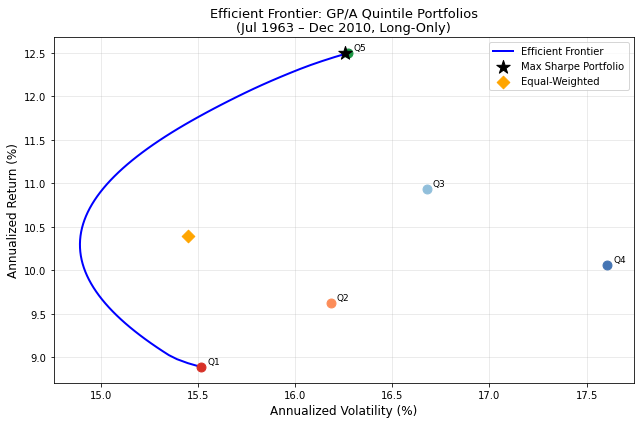


Max Sharpe weights summary:
  Concentrated in Q5 (100.0%) — the highest GP/A quintile dominates the optimal portfolio.


In [55]:
# ── Efficient Frontier ────────────────────────────────────────────────────
# Trace out the mean-variance efficient frontier by varying the target return
# and minimizing portfolio variance at each level.

def min_variance(target_ret, mu, cov):
    """Minimum variance portfolio for a given target return."""
    n = len(mu)
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: w @ mu - target_ret},
    ]
    bounds = [(0, 1)] * n
    w0 = np.ones(n) / n
    res = minimize(
        lambda w: w @ cov @ w,
        w0, method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'ftol': 1e-12, 'maxiter': 1000}
    )
    return np.sqrt(res.fun) if res.success else np.nan

# Range of target returns
target_rets = np.linspace(mu.min(), mu.max(), 80)
frontier_vols = [min_variance(t, mu, cov) for t in target_rets]
frontier_vols = np.array(frontier_vols)

# Annualize
frontier_rets_ann = target_rets * 12
frontier_vols_ann = frontier_vols * np.sqrt(12)

# Individual quintile points (annualized)
q_rets = mu * 12
q_vols = np.sqrt(np.diag(cov)) * np.sqrt(12)

fig, ax = plt.subplots(figsize=(9, 6))

# Frontier
mask = ~np.isnan(frontier_vols_ann)
ax.plot(frontier_vols_ann[mask] * 100, frontier_rets_ann[mask] * 100,
        'b-', linewidth=2, label='Efficient Frontier')

# Individual quintiles
colors_q = ['#d73027','#fc8d59','#91bfdb','#4575b4','#1a9641']
for i in range(5):
    ax.scatter(q_vols[i]*100, q_rets[i]*100,
               color=colors_q[i], s=80, zorder=5)
    ax.annotate(f'Q{i+1}', (q_vols[i]*100, q_rets[i]*100),
                textcoords='offset points', xytext=(6, 3), fontsize=9)

# Optimized portfolio
opt_ret_ann, opt_vol_ann, _ = stats_opt
ax.scatter(opt_vol_ann*100, opt_ret_ann*100,
           color='black', marker='*', s=200, zorder=6, label='Max Sharpe Portfolio')

# EW portfolio
ew_ret_ann, ew_vol_ann, _ = stats_ew
ax.scatter(ew_vol_ann*100, ew_ret_ann*100,
           color='orange', marker='D', s=80, zorder=6, label='Equal-Weighted')

ax.set_xlabel('Annualized Volatility (%)', fontsize=12)
ax.set_ylabel('Annualized Return (%)', fontsize=12)
ax.set_title('Efficient Frontier: GP/A Quintile Portfolios\n(Jul 1963 – Dec 2010, Long-Only)',
             fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMax Sharpe weights summary:")
print(f"  Concentrated in Q{w_opt.argmax()+1} ({w_opt.max()*100:.1f}%) — "
      f"the highest GP/A quintile dominates the optimal portfolio.")


The efficient frontier plot illustrates the risk-return tradeoff of long-only portfolios constructed from the five gross profitability (GP/A) quintiles. When applying mean-variance optimization to find the tangency portfolio, the plot reveals that the maximum Sharpe ratio is achieved by allocating exactly 100% of the weight to Quintile 5, the most profitable firms. Visually, the optimal portfolio on the frontier is indistinguishable from the Q5 asset itself, yielding a Sharpe ratio of 0.464 — a great improvement over a naive equal-weighted strategy. Economically, this graph demonstrates that the GP/A signal's return premium is so dominant that holding lower-profitability firms (Q1–Q4) offers no justifiable diversification benefit, making a pure concentration in the most profitable firms the mathematically optimal long-only strategy.